In [2]:
pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.4 MB/s eta 0:00:00

   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ----------------------------------------  0/11 [peewee]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- --------------------------------  2/11 [websockets]
   ------- -------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed


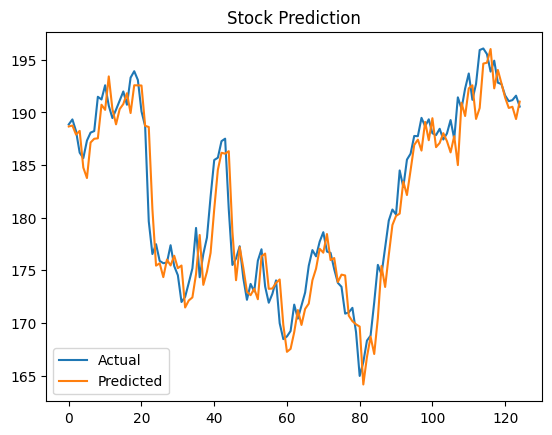

In [3]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


data = yf.download("AAPL", start="2022-01-01", end="2024-01-01")


data = data[['Open','High','Low','Volume','Close']]
data['Target'] = data['Close'].shift(-1)
data.dropna(inplace=True)

X = data[['Open','High','Low','Volume']]
y = data['Target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Plot
plt.plot(y_test.values, label='Actual')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("Stock Prediction")
plt.show()